In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
from jaxtyping import Float

import dismech_jax as djx

from util_multiset import TripletModel, validate_model, train_model, get_base_rod
from animate import animate

jax.config.update("jax_enable_x64", True)


In [2]:
def inv_softplus(y: jax.Array) -> jax.Array:
    return jnp.log(jnp.expm1(y))


class MLP(eqx.Module):
    layer1: eqx.nn.Linear
    layer2: eqx.nn.Linear

    def __init__(self, in_features: int, hidden_size: int, out_features: int, key: jax.Array):
        key1, key2 = jax.random.split(key)
        self.layer1 = eqx.nn.Linear(in_features, hidden_size, key=key1)
        self.layer2 = eqx.nn.Linear(hidden_size, out_features, key=key2)

        self.layer1 = eqx.tree_at(
            lambda l: l.weight, self.layer1, self.layer1.weight * 1e-2
        )
        self.layer2 = eqx.tree_at(
            lambda l: l.weight, self.layer2, self.layer2.weight * 1e-2
        )

    def __call__(self, x: jax.Array) -> jax.Array:
        x = jnp.ravel(x)
        x = jax.nn.tanh(self.layer1(x))
        x = self.layer2(x)
        return x   # shape (3,)
    

class Example(TripletModel):
    # internal unconstrained parameters for a 2x2 lower-triangular factor
    # not the physical [k_ss, k_sb, k_bb] directly
    K: jax.Array
    mlp: MLP

    def __init__(self, der_K: jax.Array, key: jax.Array):
        """
        der_K is the user-facing 3-vector:
            [diag_stretching, offdiag_stretch_bend, diag_bending]
          = [k_ss, k_sb, k_bb]

        This is converted internally to parameters of a Cholesky factor so that
        the resulting stiffness is symmetric PSD.
        """
        der_K = jnp.ravel(der_K)
        if der_K.shape != (3,):
            raise ValueError(f"Expected der_K shape (3,), got {der_K.shape}")

        k_ss0, k_sb0, k_bb0 = der_K
        eps = 1e-6

        # PSD check for the structured matrix
        # In the symmetric-stretch / bending basis, the 2x2 block is:
        # [[k_ss, sqrt(2) k_sb],
        #  [sqrt(2) k_sb, k_bb]]
        #
        # So PSD requires:
        #   k_ss >= 0
        #   k_bb >= 0
        #   k_ss * k_bb - 2 * k_sb^2 >= 0
        if (k_ss0 < 0) or (k_bb0 < 0) or (k_ss0 * k_bb0 - 2.0 * k_sb0**2 < 0):
            raise ValueError(
                "Initial [k_ss, k_sb, k_bb] must satisfy PSD condition: "
                "k_ss >= 0, k_bb >= 0, and k_ss*k_bb - 2*k_sb^2 >= 0."
            )

        # Convert desired physical entries to a 2x2 Cholesky factor
        l11 = jnp.sqrt(jnp.maximum(k_ss0, eps))
        l21 = jnp.sqrt(2.0) * k_sb0 / l11
        rem = k_bb0 - l21**2
        l22 = jnp.sqrt(jnp.maximum(rem, eps))

        # Store unconstrained parameters so diagonals can be enforced positive via softplus
        p0 = inv_softplus(l11 - eps)
        p1 = l21
        p2 = inv_softplus(l22 - eps)

        self.K = jnp.array([p0, p1, p2])
        self.mlp = MLP(in_features=5, hidden_size=10, out_features=3, key=key)

    def _vec_to_L(self, p: jax.Array) -> jax.Array:
        eps = 1e-6
        p = jnp.ravel(p)
        return jnp.array([
            [jax.nn.softplus(p[0]) + eps, 0.0],
            [p[1],                        jax.nn.softplus(p[2]) + eps],
        ])

    def get_K_entries(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, "3"]:
        """
        Returns the physical structured coefficients:
            [k_ss, k_sb, k_bb]
        where the energy is

            0.5*k_ss*(e0^2 + e1^2) + k_sb*(e0 + e1)*eb + 0.5*k_bb*eb^2
        """
        del_strain = jnp.ravel(del_strain)

        # small learned correction in parameter space for stability
        dp = 1e-2 * self.mlp(del_strain)
        p = self.K + dp

        L = self._vec_to_L(p)
        B = L @ L.T
        # B is the PSD 2x2 block in [symmetric-stretch, bending] basis:
        # B = [[k_ss, sqrt(2) k_sb],
        #      [sqrt(2) k_sb, k_bb]]

        k_ss = B[0, 0]
        k_sb = B[0, 1] / jnp.sqrt(2.0)
        k_bb = B[1, 1]

        return jnp.array([k_ss, k_sb, k_bb])

    def get_K_matrix(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, "3 3"]:
        """
        Full structured stiffness matrix acting on [e0, e1, eb]:
            [[k_ss,   0,   k_sb],
             [  0,  k_ss,  k_sb],
             [k_sb, k_sb,  k_bb]]
        """
        k_ss, k_sb, k_bb = self.get_K_entries(del_strain)
        return jnp.array([
            [k_ss, 0.0,  k_sb],
            [0.0,  k_ss, k_sb],
            [k_sb, k_sb, k_bb],
        ])

    def __call__(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, ""]:
        del_strain = jnp.ravel(del_strain)

        e0 = del_strain[0]
        e1 = del_strain[1]
        eb = del_strain[3]

        k_ss, k_sb, k_bb = self.get_K_entries(del_strain)

        stretching_energy = 0.5 * k_ss * (e0**2 + e1**2)
        coupling_energy = k_sb * (e0 + e1) * eb
        bending_energy = 0.5 * k_bb * eb**2

        return stretching_energy + coupling_energy + bending_energy

In [3]:
from util import TestCase

# train_file = "output.npz"
# valid_file = "output_valid.npz"

train_file = "combined_output_train_new.npz"
valid_file = "combined_output_valid_new.npz"

init_K=jnp.array([2, 0.01, 0.02])
validate_model(Example, der_K=init_K)

final_model, init_K, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file=train_file, valid_file=valid_file, n_epochs=500, lr=1e-2, init_K=init_K )
# final_model, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file="output_valid.npz", valid_file="output_valid.npz", n_epochs=100, lr=1e-2)

print( "initial K: ", init_K)
print( "learned K: ", final_model.get_K_entries(jnp.zeros(5)) )

xb_c:  [0.  0.  0.  0.  0.  0.5 0.  0. ]
xb_c:  [0.  0.  0.  0.  0.  0.5 0.  0. ]
lambdas:  JitTracer(float64[11])


/Users/radha/GitRepos/dismech-jax/examples/slinky/util_multiset.py:50: UserWarning: combined_output_train_new.npz: expected xb_c to have shape (n_traj, n_b), got shape (5, 8). Using same xb_c for all trajectories.
  warnings.warn(
/Users/radha/GitRepos/dismech-jax/examples/slinky/util_multiset.py:50: UserWarning: combined_output_valid_new.npz: expected xb_c to have shape (n_traj, n_b), got shape (5, 8). Using same xb_c for all trajectories.
  warnings.warn(


lambdas:  JitTracer(float64[11])
Step 0    | LR: 1.000e-02  | Train: 9.24161e-05  | Valid: 9.49065e-05  | K: [ 1.14566564  0.01999993 -1.8771642 ]
Step 10   | LR: 9.991e-03  | Train: 5.01649e-05  | Valid: 7.04825e-05  | K: [ 1.18522912  0.08707863 -1.79706787]
Step 20   | LR: 9.965e-03  | Train: 3.98180e-05  | Valid: 5.64257e-05  | K: [ 1.11901236  0.07368359 -1.76424301]
Step 30   | LR: 9.921e-03  | Train: 3.39737e-05  | Valid: 4.69587e-05  | K: [ 1.0604148   0.07835369 -1.70523372]
Step 40   | LR: 9.859e-03  | Train: 2.62703e-05  | Valid: 3.63810e-05  | K: [ 1.00533132  0.09422956 -1.63259195]
Step 50   | LR: 9.781e-03  | Train: 1.79062e-05  | Valid: 2.35984e-05  | K: [ 0.93675596  0.09234868 -1.57065425]
Step 60   | LR: 9.685e-03  | Train: 1.03465e-05  | Valid: 1.28447e-05  | K: [ 0.87833245  0.09921299 -1.49874866]
Step 70   | LR: 9.573e-03  | Train: 4.66750e-06  | Valid: 4.77553e-06  | K: [ 0.82419613  0.10059022 -1.43775026]
Step 80   | LR: 9.446e-03  | Train: 1.66876e-06  | Vali

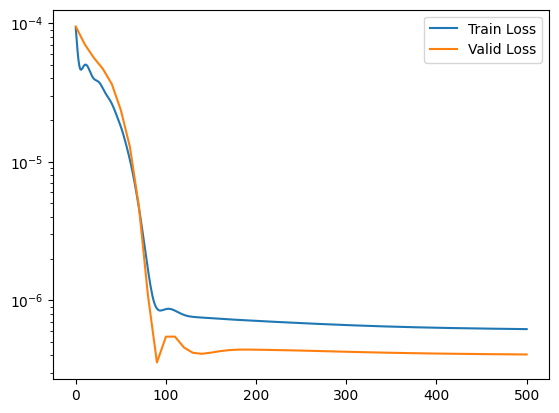

In [4]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [5]:
train = TestCase.from_npz(train_file)
valid = TestCase.from_npz(valid_file)
# train = TestCase.from_npz("output_valid.npz")
# valid = TestCase.from_npz("output_valid.npz")
print("Train:")
print("fixed idx:", train.bc.idx_b)
print("slope:", train.bc.xb_m)
print("intercept:", train.bc.xb_c)
print("Valid:")
print("fixed idx:", valid.bc.idx_b)
print("slope:", valid.bc.xb_m)
print("intercept:", valid.bc.xb_c)
lambdas = jnp.linspace(0.0, 1.0, valid.qs.shape[1])


Train:
fixed idx: [ 0  1  2  3  7  8  9 10]
slope: [[[ 0.    0.    0.    0.    0.   -0.1   0.   -0.05]]

 [[ 0.    0.    0.    0.    0.   -0.08  0.    0.04]]

 [[ 0.    0.    0.    0.    0.    0.2   0.   -0.03]]

 [[ 0.    0.    0.    0.    0.    0.5   0.    0.  ]]

 [[ 0.    0.    0.    0.    0.   -0.02  0.   -0.1 ]]]
intercept: [0.  0.  0.  0.  0.  0.5 0.  0. ]
Valid:
fixed idx: [ 0  1  2  3  7  8  9 10]
slope: [[[ 0.    0.    0.    0.    0.   -0.12  0.    0.02]]

 [[ 0.    0.    0.    0.    0.   -0.1   0.   -0.02]]

 [[ 0.    0.    0.    0.    0.   -0.08  0.    0.03]]

 [[ 0.    0.    0.    0.    0.    0.6   0.   -0.04]]

 [[ 0.    0.    0.    0.    0.    0.4   0.    0.05]]]
intercept: [0.  0.  0.  0.  0.  0.5 0.  0. ]


In [19]:

print(valid.bc)
base, aux, _ = get_base_rod()
rods = base.with_bc(valid.bc)
print("Base rod: ", base)
print("Rods: ", rods)
pred = rods.solve(final_model, lambdas, aux, max_dlambda=5e-3, iters=5, ls_steps=10)
print(pred)
print(pred.shape)
print(valid.qs.shape)
print(train.qs.shape)
# animate(pred)

BatchedLinearBC(idx_b=i64[8](numpy), xb_m=f64[5,1,8](numpy), xb_c=f64[8](numpy))
Base rod:  Rod(
  triplets=Triplet(bar_strain=f64[1,5], l_k=f64[1,2]),
  mass=f64[11],
  q0=f64[11],
  E_ext=Gravity(F_ext=f64[11]),
  bc=AbstractBC()
)
Rods:  Rod(
  triplets=Triplet(bar_strain=f64[1,5], l_k=f64[1,2]),
  mass=f64[11],
  q0=f64[11],
  E_ext=Gravity(F_ext=f64[11]),
  bc=BatchedLinearBC(
    idx_b=i64[8](numpy), xb_m=f64[5,1,8](numpy), xb_c=f64[8](numpy)
  )
)
[[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
    2.50884870e-01  1.78398174e-05 -1.70609927e-01  0.00000000e+00
    5.00000000e-01  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
    2.45149931e-01  1.92249199e-05 -1.70395277e-01  0.00000000e+00
    4.88000000e-01  0.00000000e+00  2.00000000e-03]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
    2.39433421e-01  1.99151396e-05 -1.70095313e-01  0.00000000e+00
    4.76000000e-01  0.00000000e+00 

In [18]:
# animate(valid.qs)

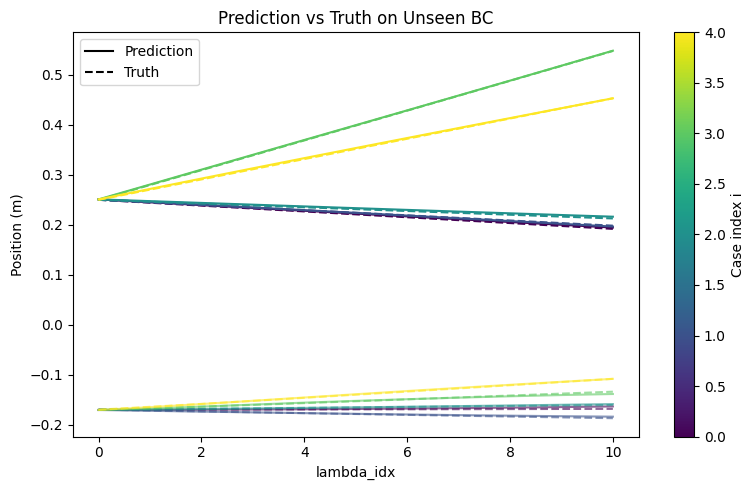

In [20]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
import jax.numpy as jnp

n_cases = pred.shape[0]
colors = cm.viridis(jnp.linspace(0, 1, n_cases))

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(n_cases):
    c = colors[i]

    # X
    ax.plot(pred[i, :, 4], color=c, linestyle='-')
    ax.plot(valid.qs[i, :, 4], color=c, linestyle='--')

    # Z
    ax.plot(pred[i, :, 6], color=c, linestyle='-', alpha=0.6)
    ax.plot(valid.qs[i, :, 6], color=c, linestyle='--', alpha=0.6)

pred_line = mlines.Line2D([], [], color='black', linestyle='-', label='Prediction')
truth_line = mlines.Line2D([], [], color='black', linestyle='--', label='Truth')
ax.legend(handles=[pred_line, truth_line])

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=n_cases - 1))
sm.set_array([])  # helps matplotlib know this is a valid mappable
fig.colorbar(sm, ax=ax, label='Case index i')

ax.set_title("Prediction vs Truth on Unseen BC")
ax.set_xlabel("lambda_idx")
ax.set_ylabel("Position (m)")
fig.tight_layout()
plt.show()

In [9]:
print("Training BC:")
print("init: ", train.qs[0, 8:11])
print("final: ", train.qs[-1, 8:11])

print("Validation BC:")
print("init: ", valid.qs[0, 8:11])
print("final: ", valid.qs[-1, 8:11])

Training BC:
init:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.06445734e-01  5.23079694e-05 -1.95548770e-01  0.00000000e+00
   4.20000000e-01  0.00000000e+00 -4.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.00984620e-01  5.92194272e-05 -1.98657304e-01  0.00000000e+00
   4.10000000e-01  0.00000000e+00 -4.50000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.95521151e-01  6.64904575e-05 -2.01744441e-01  0.00000000e+00
   4.00000000e-01  0.00000000e+00 -5.00000000e-02]]
final:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.35116853e-01  8.26279574e-05 -2.10220639e-01  0.00000000e+00
   4.84000000e-01  0.00000000e+00 -8.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.33256103e-01  9.21699186e-05 -2.15117321e-01  0.00000000e+00
   4.82000000e-01  0.00000000e+00 -9.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.000

In [10]:
print("initial position of the middle node in the training data: ", train.qs[0, 4:7])
print("final position of the middle node in the training data: ", train.qs[-1, 4:7])

initial position of the middle node in the training data:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.28259057e-01  2.73439887e-05 -1.82906749e-01  0.00000000e+00
   4.60000000e-01  0.00000000e+00 -2.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.22810780e-01  3.31527109e-05 -1.86097787e-01  0.00000000e+00
   4.50000000e-01  0.00000000e+00 -2.50000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.17359081e-01  3.92855092e-05 -1.89268693e-01  0.00000000e+00
   4.40000000e-01  0.00000000e+00 -3.00000000e-02]]
final position of the middle node in the training data:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.42566804e-01  4.35265118e-05 -1.90327232e-01  0.00000000e+00
   4.92000000e-01  0.00000000e+00 -4.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.40704004e-01  5.33826897e-05 -1.95346428e-01  0.00000000e+00
   4.90000000e-01  

In [11]:
print("initial position of the middle node in the validation data: ", valid.qs[0, 4:7])
print("final position of the middle node in the validation data: ", valid.qs[-1, 4:7])

initial position of the middle node in the validation data:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.26715498e-01 -2.30803296e-06 -1.69538647e-01  0.00000000e+00
   4.52000000e-01  0.00000000e+00  8.00000000e-03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.20896435e-01 -4.88784212e-06 -1.69390319e-01  0.00000000e+00
   4.40000000e-01  0.00000000e+00  1.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.15079260e-01 -7.54219665e-06 -1.69222700e-01  0.00000000e+00
   4.28000000e-01  0.00000000e+00  1.20000000e-02]]
final position of the middle node in the validation data:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   3.31532499e-01 -2.50656330e-05 -1.46300712e-01  0.00000000e+00
   6.60000000e-01  0.00000000e+00  2.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   3.51857561e-01 -2.76286060e-05 -1.40098242e-01  0.00000000e+00
   7.00000000e-

In [12]:
print("initial position of the middle node in the prediction: ", pred[0, 4:7])
print("final position of the middle node in the prediction: ", pred[-1, 4:7])

initial position of the middle node in the prediction:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.28060314e-01  2.08983514e-05 -1.69203233e-01  0.00000000e+00
   4.52000000e-01  0.00000000e+00  8.00000000e-03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.22405902e-01  2.11939834e-05 -1.68592492e-01  0.00000000e+00
   4.40000000e-01  0.00000000e+00  1.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.16774302e-01  2.13642772e-05 -1.67859190e-01  0.00000000e+00
   4.28000000e-01  0.00000000e+00  1.20000000e-02]]
final position of the middle node in the prediction:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   3.33386135e-01 -8.64722053e-07 -1.45633804e-01  0.00000000e+00
   6.60000000e-01  0.00000000e+00  2.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   3.53576809e-01 -5.90627503e-06 -1.39088324e-01  0.00000000e+00
   7.00000000e-01  0.0000